In [ ]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import baltic as bt
import re
from collections import defaultdict
import pandas as pd

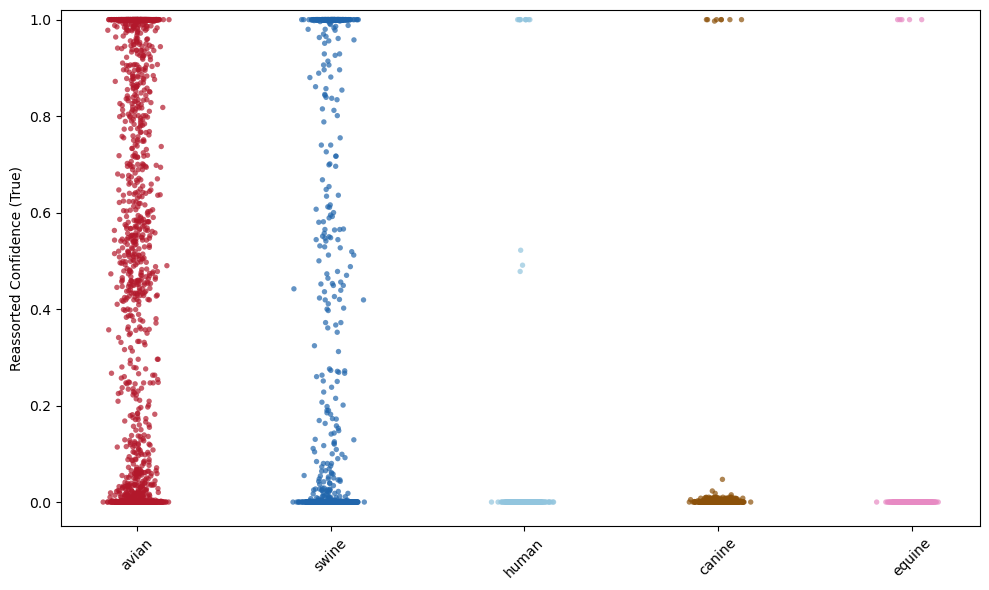

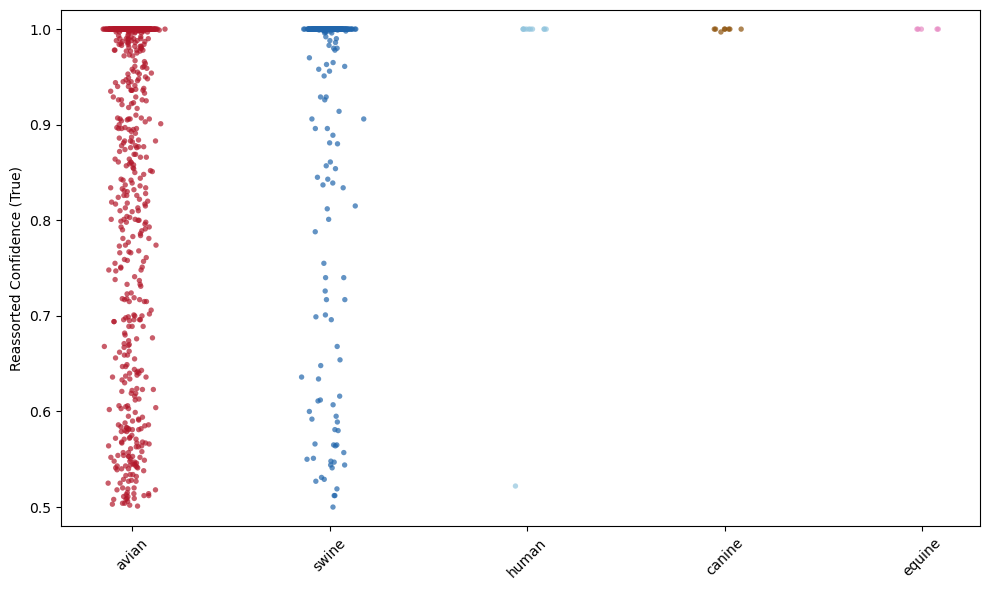

In [33]:
json_folder = "jsons"
clades = ['avian', 'swine', 'human', 'canine', 'equine']

colors = [
    "#b2182b", 
    "#2166ac",  
    "#92c5de",  
    "#8c510a", 
    "#e78ac3"
]

plot_data = {}
for clade in clades:
    file_path = os.path.join(json_folder, f"{clade}.json")
    with open(file_path, "r") as file:
        data = json.load(file)
    
    true_conf_values = [
        node_data["reassorted_confidence"].get("True", np.nan)
        for node_data in data["nodes"].values()
        if "reassorted_confidence" in node_data
    ]
    plot_data[clade] = [v for v in true_conf_values if not np.isnan(v)]

plt.figure(figsize=(10, 6))
for i, clade in enumerate(clades):
    y_values = plot_data[clade]
    x_values = np.random.normal(i + 1, 0.05, size=len(y_values))  # jitter
    plt.scatter(x_values, y_values, color=colors[i], s=15, alpha=0.7, edgecolors='none')

plt.xticks(range(1, len(clades) + 1), clades, rotation=45)
plt.ylim(-0.05, 1.02)
plt.ylabel("Reassorted Confidence (True)")
plt.tight_layout()
plt.show()

# y-axis starts at 0.5 ---
plt.figure(figsize=(10, 6))
for i, clade in enumerate(clades):
    y_values = [v for v in plot_data[clade] if v >= 0.5]
    x_values = np.random.normal(i + 1, 0.05, size=len(y_values))  # jitter
    plt.scatter(x_values, y_values, color=colors[i], s=15, alpha=0.7, edgecolors='none')
        
plt.xticks(range(1, len(clades) + 1), clades, rotation=45)
plt.ylim(0.48, 1.02)
plt.ylabel("Reassorted Confidence (True)")
plt.tight_layout()
plt.show()



In [2]:
json_folder = "jsons"
clades = ['avian', 'swine', 'human', 'canine', 'equine']

colors = [
    "#b2182b", 
    "#2166ac",  
    "#92c5de",  
    "#8c510a", 
    "#e78ac3"
]

plot_data = {}
for clade in clades:
    file_path = os.path.join(json_folder, f"{clade}.json")
    with open(file_path, "r") as file:
        data = json.load(file)
        
        
    
    
    true_conf_values = [
        node_data["reassorted_confidence"].get("True", np.nan)
        for node_data in data["nodes"].values()
        if "reassorted_confidence" in node_data
    ]
    plot_data[clade] = [v for v in true_conf_values if not np.isnan(v)]


In [ ]:
clades = ['h3nx','avian', 'swine', 'human', 'canine', 'equine']

plot_data = defaultdict(lambda: defaultdict(dict))

for clade in clades:

    mytree = bt.loadNewick(f'host_trees/{clade}.nwk', absoluteTime= False)
    
    for k in mytree.Objects:
        
        if k.is_leaf():
            plot_data[clade][k.name]["div"] = k.height
            plot_data[clade][k.name]["type"] = 'leaf'
            
        if k.is_node():
            plot_data[clade][k.traits["label"]]["div"] = k.height
            plot_data[clade][k.traits["label"]]["type"] = 'node'
            

    with open(f'jsons/{clade}.json', "r") as file:
        data = json.load(file)
        
    for name, node_data in data["nodes"].items():
        
        plot_data[clade][name]['support'] = node_data["reassorted_confidence"].get("True", np.nan)
        

In [ ]:
# smaller height = closer to the root
# y-axis is support
# x-axis is height

rows = []
for clade, nodes in plot_data.items():
    for name, vals in nodes.items():
        rows.append({
            "clade": clade,
            "name": name,
            "div": vals["div"],
            "type": vals["type"],
            "support": vals["support"]
        })

df = pd.DataFrame(rows)

df


,clade,name,div,type,support
0,h3nx,TS_NODE_5259,0.00100,node,0.000
1,h3nx,TS_NODE_2305,0.00923,node,0.737
2,h3nx,TS_NODE_8,0.01299,node,0.736
3,h3nx,A/duck/Hokkaido/5/1977|1977-01-01,0.03043,leaf,0.000
4,h3nx,TS_NODE_7,0.02020,node,1.000
...,...,...,...,...,...
18699,equine,NODE_214,0.04370,node,0.000
18700,equine,A/equine/Switzerland/1118/1979|1979-01-01,0.04370,leaf,0.000
18701,equine,A/equine/Romania/1/1980|1980-01-01,0.04660,leaf,0.000
18702,equine,A/equine/France/1/1967|1967-01-01,0.04370,leaf,0.000


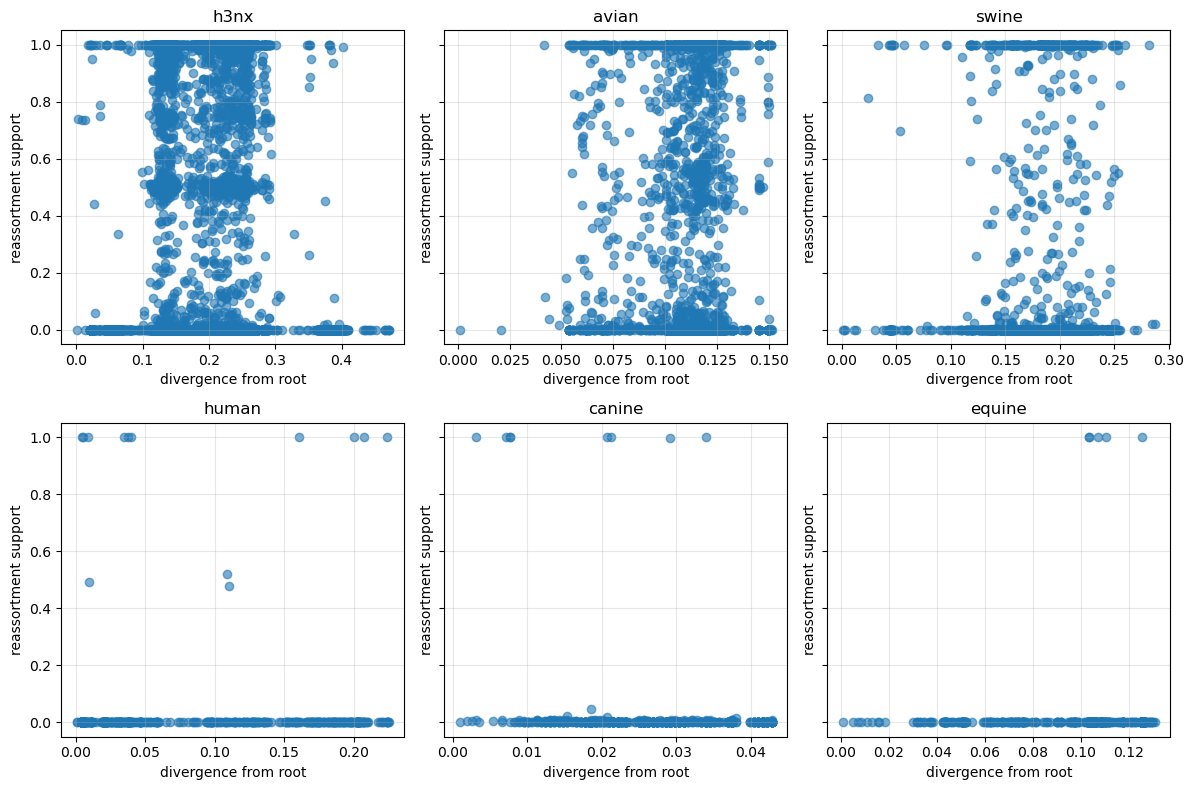

In [90]:
clades = df["clade"].unique()
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=False, sharey=True)

axes = axes.flatten()

for ax, clade in zip(axes, clades):
    subset = df[df["clade"] == clade]
    ax.scatter( subset["div"],subset["support"], alpha=0.6)
    ax.set_title(clade)
    ax.set_ylabel("reassortment support")
    ax.set_xlabel("divergence from root")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


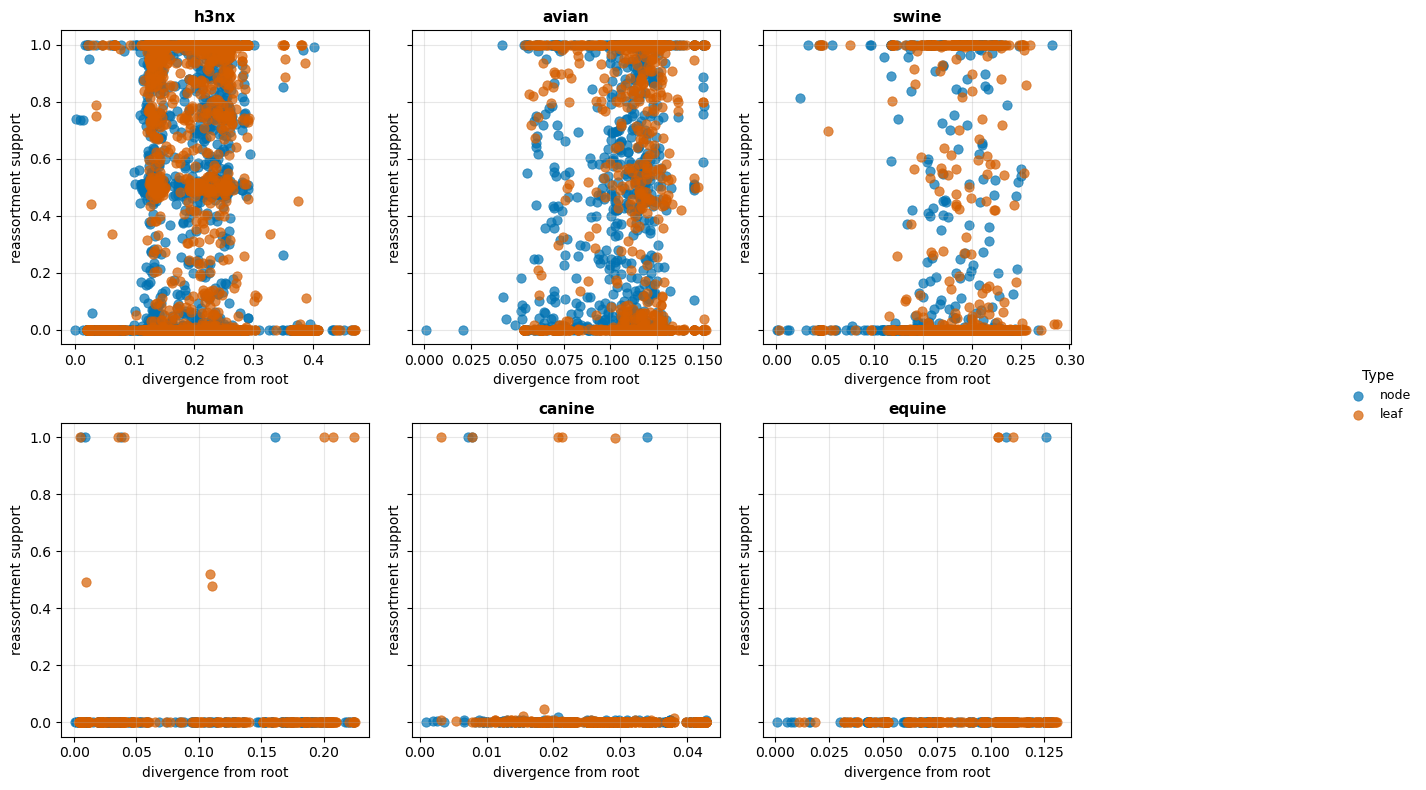

In [108]:
types = df["type"].unique()
colors = ["#0072B2", "#D55E00"]
color_map = dict(zip(types, colors))

clades = df["clade"].unique()
fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=False, sharey=True)
axes = axes.flatten()

for ax, clade in zip(axes, clades):
    subset = df[df["clade"] == clade]
    for t in types:
        t_subset = subset[subset["type"] == t]
        ax.scatter(
            t_subset["div"],
            t_subset["support"],
            alpha=0.7,
            s=45,
            label=t,
            color=color_map[t],
            linewidth=0.6
        )
    ax.set_title(clade, fontsize=11, weight="semibold")
    ax.set_ylabel("reassortment support", fontsize=10)
    ax.set_xlabel("divergence from root", fontsize=10)
    ax.grid(True, alpha=0.3)

# Shared legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Type",
    loc="center left",
    bbox_to_anchor=(1.03, 0.5),
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

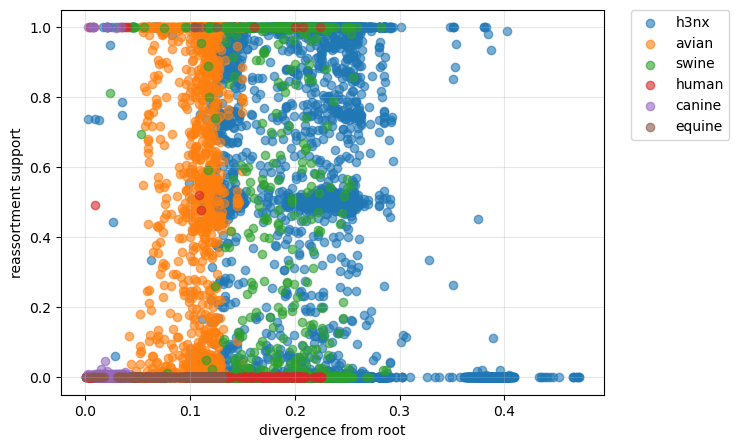

In [67]:
plt.figure(figsize=(7,5))
for clade in df["clade"].unique():
    subset = df[df["clade"] == clade]
    plt.scatter(subset["div"], subset["support"], label=clade, alpha=0.6)

plt.xlabel("divergence from root")
plt.ylabel("reassortment support")
plt.legend(
    bbox_to_anchor=(1.05, 1),  # position legend outside the plot (to the right)
    loc='upper left',
    borderaxespad=0.
)
plt.grid(True, alpha=0.3)
plt.show()
